# Honest Evaluation — Per-Transaction Test Metrics

An audit of the published evaluation found that the headline LSTM metrics (Precision 0.98 / Recall 0.95 at t\*=0.2792, PR-AUC 0.9865) are computed **per window, not per transaction**. The window builder (`lookback=32`, `stride=2`, cards with fewer than 32 transactions skipped) scores only 136,737 window endpoints containing **641 of the 1,447 fraud transactions in the test slice** — the other ~56% of fraud is never evaluated, and the low-history regime the production API must still score is entirely absent from the metrics.

This notebook re-scores the **unchanged deployed model** on **every transaction in the test slice**, using the same zero-left-padding for short histories that the production service (`service_raw.py`) applies. Thresholds are not re-tuned: we evaluate at the pre-registered operating points chosen on validation in the original notebooks — the F1-optimal t\* = 0.2792 and the deployed cost-optimal t = 0.011.

Steps:
1. Rebuild the modeling frame from the raw CSVs (same recipe as `Logistic_models.ipynb`).
2. Recreate the card-sorted 70/15/15 split used by the LSTM notebooks.
3. Parity check — reproduce the original per-window test set and published confusion matrix, proving we are auditing the same model and data.
4. Score all 277,858 test transactions (stride 1, zero-padded short histories).
5. Corrected metrics + a breakdown showing where the previously hidden fraud lands.

In [1]:
import os, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from joblib import load as joblib_load
from tensorflow import keras
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve)

# Works from the flat local folder or from NoteBooks/ in the repo layout
DATA_DIR = Path('.') if Path('fraudTrain.csv').exists() else Path('..')
ART_DIR = next(p for p in [Path('artifacts_fraud_detec'),
                           Path('../Model_Deployment/Artifacts'),
                           Path('Model_Deployment/Artifacts')] if p.exists())
print('data:', DATA_DIR.resolve(), '| artifacts:', ART_DIR.resolve())

data: /Users/ryanmurray/Documents/Project_Folder/Fraud_detection | artifacts: /Users/ryanmurray/Documents/Project_Folder/Fraud_detection/artifacts_fraud_detec


## 1. Rebuild the modeling frame

Same recipe as the analysis notebooks: concatenate `fraudTrain.csv` + `fraudTest.csv`, drop the `state == 'DE'` artefact rows (9 records, 100% fraud rate — synthetic-generator artefact), derive `trans_hour`, and compute the per-card burst features `time_since_last` and `last_amt` from past-only information. `time_since_last` is the wall-clock datetime diff (as in `Fraud_analysis.ipynb`), which reproduces the saved preprocessor's statistics exactly — the `unix_time` diff used in `Logistic_models.ipynb` differs on a handful of rows across DST transitions.

In [2]:
raw_train = pd.read_csv(DATA_DIR / 'fraudTrain.csv')
raw_test = pd.read_csv(DATA_DIR / 'fraudTest.csv')
df = pd.concat([raw_train, raw_test], ignore_index=True)
df.drop(df[df['state'] == 'DE'].index, inplace=True)

df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_hour'] = df['trans_date_trans_time'].dt.hour
df = df.sort_values(by=['cc_num', 'trans_date_trans_time']).reset_index(drop=True)
df['time_since_last'] = df.groupby('cc_num')['trans_date_trans_time'].diff().dt.total_seconds().fillna(-1)
df['last_amt'] = df.groupby('cc_num')['amt'].shift(1).fillna(0)

cols = ['trans_date_trans_time', 'cc_num', 'category', 'amt', 'is_fraud',
        'trans_hour', 'time_since_last', 'last_amt']
nn_df = df[cols].sort_values('trans_date_trans_time')
del df, raw_train, raw_test
print(f"rows: {len(nn_df):,} | fraud: {nn_df['is_fraud'].sum():,} ({nn_df['is_fraud'].mean():.4%})")

rows: 1,852,385 | fraud: 9,642 (0.5205%)


## 2. Recreate the LSTM split

`Deep_models.ipynb` sorts by `(cc_num, trans_date_trans_time)` and slices positionally at 70% / 85%. Because the frame is card-sorted, this is effectively a **by-card split spanning the full 2019–2020 period** (two boundary cards straddle splits) — *not* a chronological split. We keep it identical here so the corrected numbers are directly comparable with the published ones; the split-design caveat is discussed in the README.

In [3]:
LSTM_df = nn_df.copy()
LSTM_df.sort_values(['cc_num', 'trans_date_trans_time'], inplace=True)
LSTM_df.reset_index(drop=True, inplace=True)

n = len(LSTM_df)
x, i = int(0.7 * n), int(0.85 * n)
train_LSTM = LSTM_df.iloc[:x]
test_LSTM = LSTM_df.iloc[i:].reset_index(drop=True)

print(f"test slice: {len(test_LSTM):,} transactions | "
      f"fraud: {test_LSTM['is_fraud'].sum():,} ({test_LSTM['is_fraud'].mean():.4%}) | "
      f"cards: {test_LSTM['cc_num'].nunique()}")

test slice: 277,858 transactions | fraud: 1,447 (0.5208%) | cards: 155


## 3. Load deployed artifacts & parity-check the published evaluation

We load the exact model + preprocessor shipped in the deployment artifacts, verify the saved preprocessor matches one freshly fit on the training slice, rebuild the original stride-2 / no-padding window set, and reproduce the published confusion matrix. Published values (Deep_models.ipynb): 136,737 windows, 641 fraud; at 0.5 → TN=136086, FP=10, FN=31, TP=610; at t\*=0.2792 → TN=136082, FP=14, FN=29, TP=612.

In [4]:
model = keras.models.load_model(ART_DIR / 'lstm_fraud_model.keras')
pre = joblib_load(ART_DIR / 'preprocessor.joblib')
t_cost = float(json.load(open(ART_DIR / 'threshold.json'))['t_star'])  # deployed, 0.011
t_f1 = 0.2792                                                          # F1-optimal, chosen on validation
features = ['amt', 'trans_hour', 'time_since_last', 'last_amt', 'category']

# The saved preprocessor must equal one fit on the training slice (as in training)
check = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), features[:4]),
    ('cat', Pipeline([('encode', OneHotEncoder(drop='first', handle_unknown='ignore',
                                               sparse_output=False))]), features[4:]),
]).fit(train_LSTM[features])
sample = test_LSTM[features].head(2000)
assert np.allclose(pre.transform(sample), check.transform(sample)), "saved preprocessor != training fit"
print(f"preprocessor parity OK | deployed threshold t={t_cost:.6f}")

X_test = pre.transform(test_LSTM[features]).astype(np.float32)
y_test = test_LSTM['is_fraud'].to_numpy().astype(int)
print('encoded test matrix:', X_test.shape)

preprocessor parity OK | deployed threshold t=0.011005
encoded test matrix: (277858, 17)


In [5]:
T = 32
grp = test_LSTM.groupby('cc_num', sort=False)
pos = grp.cumcount().to_numpy()                      # position of each row within its card
card_size = grp['cc_num'].transform('size').to_numpy()

# Rows the original evaluation scored: cards with >=32 txns, window ends at
# positions 31, 33, 35, ... (lookback 32, stride 2)
orig_scored = (card_size >= T) & (pos >= T - 1) & ((pos - (T - 1)) % 2 == 0)
assert orig_scored.sum() == 136737, orig_scored.sum()
assert y_test[orig_scored].sum() == 641

# Rebuild those windows and score them with the deployed model
starts = np.where(orig_scored)[0] - (T - 1)
X_orig = np.stack([X_test[s:s + T] for s in starts])
p_orig = model.predict(X_orig, batch_size=2048, verbose=0).ravel()
y_orig = y_test[orig_scored]

for t, name in [(0.5, '0.5'), (t_f1, 't*=0.2792')]:
    tn, fp, fn, tp = confusion_matrix(y_orig, (p_orig >= t).astype(int), labels=[0, 1]).ravel()
    print(f"per-window @ {name}: TN={tn} FP={fp} FN={fn} TP={tp}")
print(f"per-window PR-AUC={average_precision_score(y_orig, p_orig):.4f} "
      f"ROC-AUC={roc_auc_score(y_orig, p_orig):.4f}   <- should match the published 0.9865 / 0.9993")
del X_orig

per-window @ 0.5: TN=136086 FP=10 FN=31 TP=610
per-window @ t*=0.2792: TN=136082 FP=14 FN=29 TP=612
per-window PR-AUC=0.9865 ROC-AUC=0.9993   <- should match the published 0.9865 / 0.9993


## 4. Score every transaction in the test slice

For each of the 277,858 test transactions we build the window of up to 32 same-card transactions ending at it, zero-left-padded when fewer — exactly what `last_T_window()` in `service_raw.py` does in production. Stride 1, no minimum history, no card excluded.

In [6]:
def padded_windows(X_rows, frame, T=32):
    """(N, T, F) windows: one per row, per-card sliding, zero-left-padded."""
    N, F = X_rows.shape
    out = np.zeros((N, T, F), dtype=np.float32)
    start = 0
    for _, block in frame.groupby('cc_num', sort=False):
        m = len(block)
        padded = np.vstack([np.zeros((T - 1, F), dtype=np.float32),
                            X_rows[start:start + m]])
        out[start:start + m] = np.lib.stride_tricks.sliding_window_view(
            padded, (T, F)).squeeze(1)
        start += m
    return out

X_all = padded_windows(X_test, test_LSTM)
history = np.minimum(pos + 1, T)          # real (non-padded) rows in each window
assert len(X_all) == len(test_LSTM)
print('windows:', X_all.shape)

p_all = model.predict(X_all, batch_size=2048, verbose=0).ravel()
del X_all
print('scored', len(p_all), 'transactions')

windows: (277858, 32, 17)


scored 277858 transactions


## 5. Corrected per-transaction metrics

Same model, same thresholds — the only change is that every transaction now counts.

In [7]:
print(f"PER-TRANSACTION  PR-AUC={average_precision_score(y_test, p_all):.4f} | "
      f"ROC-AUC={roc_auc_score(y_test, p_all):.4f}  (n={len(y_test):,}, fraud={y_test.sum():,})\n")

for t, name in [(t_f1, 'F1-optimal t*=0.2792'), (t_cost, 'deployed cost-optimal t=0.011')]:
    pred = (p_all >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    prec, rec = tp / (tp + fp), tp / (tp + fn)
    f1 = 2 * prec * rec / (prec + rec)
    print(f"@ {name}")
    print(f"  TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")
    print(f"  Precision={prec:.4f} | Recall={rec:.4f} | F1={f1:.4f}\n")

print(classification_report(y_test, (p_all >= t_f1).astype(int), digits=4))

PER-TRANSACTION  PR-AUC=0.9659 | ROC-AUC=0.9994  (n=277,858, fraud=1,447)

@ F1-optimal t*=0.2792
  TN=276,077 FP=334 FN=65 TP=1,382
  Precision=0.8054 | Recall=0.9551 | F1=0.8739

@ deployed cost-optimal t=0.011
  TN=275,821 FP=590 FN=34 TP=1,413
  Precision=0.7054 | Recall=0.9765 | F1=0.8191

              precision    recall  f1-score   support

           0     0.9998    0.9988    0.9993    276411
           1     0.8054    0.9551    0.8739      1447

    accuracy                         0.9986    277858
   macro avg     0.9026    0.9769    0.9366    277858
weighted avg     0.9988    0.9986    0.9986    277858



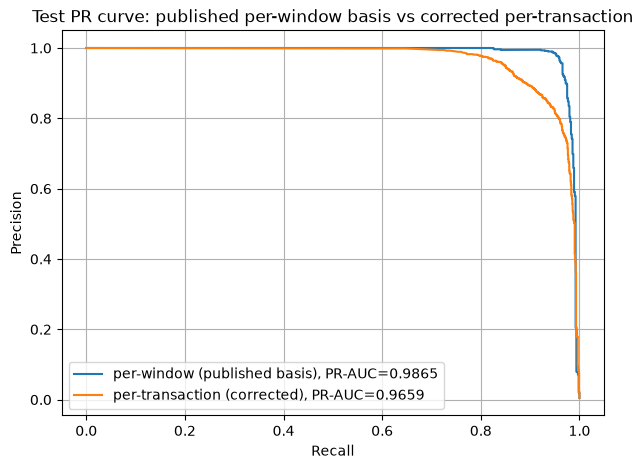

In [8]:
prec_c, rec_c, _ = precision_recall_curve(y_test, p_all)
prec_w, rec_w, _ = precision_recall_curve(y_orig, p_orig)

plt.figure(figsize=(7, 5))
plt.plot(rec_w, prec_w, label=f'per-window (published basis), PR-AUC={average_precision_score(y_orig, p_orig):.4f}')
plt.plot(rec_c, prec_c, label=f'per-transaction (corrected), PR-AUC={average_precision_score(y_test, p_all):.4f}')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Test PR curve: published per-window basis vs corrected per-transaction')
plt.grid(True); plt.legend(); plt.show()

## 6. Where the difference comes from

Splitting the test slice by how much real card history each window contains — and by whether the original evaluation scored the row — shows exactly what the per-window basis hid. Two facts stand out:

- **Recall holds everywhere**, including the 806 previously unscored fraud cases and even cold-start windows: on this synthetic data the burst/amount signal is strong enough that catching fraud needs little card history.
- **False positives explode as history shrinks.** Training only ever saw full 32-transaction windows, so the zero-padded windows production builds for new cards are out-of-distribution — and the model fires on a large share of *legitimate* low-history transactions.

In [9]:
seg = pd.DataFrame({'y': y_test, 'p': p_all, 'history': history, 'orig_scored': orig_scored})

def seg_row(mask, label):
    s = seg[mask]
    fraud, legit = int(s['y'].sum()), int((s['y'] == 0).sum())
    row = {'segment': label, 'transactions': len(s), 'fraud': fraud}
    for t, tag in [(t_f1, 't*'), (t_cost, 't=0.011')]:
        flag = s['p'] >= t
        row[f'recall@{tag}'] = np.nan if fraud == 0 else round((flag & (s['y'] == 1)).sum() / fraud, 4)
        row[f'FPR@{tag}'] = round((flag & (s['y'] == 0)).sum() / max(1, legit), 5)
    return row

buckets = [
    (seg['history'] == 32, 'full history (32)'),
    (seg['history'].between(17, 31), 'history 17-31'),
    (seg['history'].between(5, 16), 'history 5-16'),
    (seg['history'] <= 4, 'history 1-4 (cold start)'),
    (seg['orig_scored'], 'scored by original eval'),
    (~seg['orig_scored'], 'NOT scored by original eval'),
    (seg['history'] > 0, 'ALL test transactions'),
]
summary = pd.DataFrame([seg_row(m, l) for m, l in buckets])
print(summary.to_string(index=False))

hidden_fraud = int(seg.loc[~seg['orig_scored'], 'y'].sum())
print(f"\nfraud transactions invisible to the original evaluation: {hidden_fraud} "
      f"of {int(seg['y'].sum())} ({hidden_fraud / seg['y'].sum():.1%})")

cold = seg['history'] <= 4
for t, tag in [(t_f1, 't*'), (t_cost, 'deployed t')]:
    fp_all = int(((seg['p'] >= t) & (seg['y'] == 0)).sum())
    fp_cold = int(((seg['p'] >= t) & (seg['y'] == 0) & cold).sum())
    print(f"false positives @ {tag}: {fp_all} total, {fp_cold} ({fp_cold/fp_all:.0%}) from the "
          f"{int(cold.sum())} cold-start transactions")

                    segment  transactions  fraud  recall@t*  FPR@t*  recall@t=0.011  FPR@t=0.011
          full history (32)        273403   1270     0.9512 0.00011          0.9756      0.00069
              history 17-31          2085     15     1.0000 0.00048          1.0000      0.00242
               history 5-16          1750     96     0.9896 0.02297          0.9896      0.03446
   history 1-4 (cold start)           620     66     0.9697 0.47653          0.9697      0.61191
    scored by original eval        136737    641     0.9548 0.00010          0.9750      0.00069
NOT scored by original eval        141121    806     0.9553 0.00228          0.9777      0.00353
      ALL test transactions        277858   1447     0.9551 0.00121          0.9765      0.00213

fraud transactions invisible to the original evaluation: 806 of 1447 (55.7%)
false positives @ t*: 334 total, 264 (79%) from the 620 cold-start transactions
false positives @ deployed t: 590 total, 339 (57%) from the 620 co

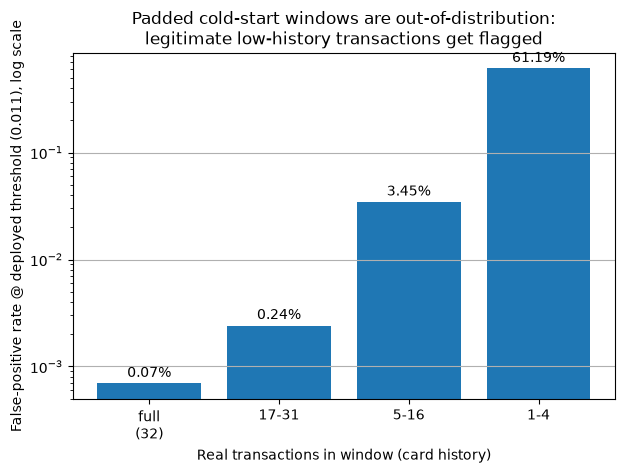

In [10]:
bucket_masks = [(seg['history'] == 32, 'full\n(32)'),
                (seg['history'].between(17, 31), '17-31'),
                (seg['history'].between(5, 16), '5-16'),
                (seg['history'] <= 4, '1-4')]
labels = [l for _, l in bucket_masks]
fprs = [((seg[m]['p'] >= t_cost) & (seg[m]['y'] == 0)).sum() / max(1, (seg[m]['y'] == 0).sum())
        for m, _ in bucket_masks]

plt.figure(figsize=(7, 4.5))
bars = plt.bar(labels, fprs)
for b, v in zip(bars, fprs):
    plt.text(b.get_x() + b.get_width() / 2, v * 1.15, f'{v:.2%}', ha='center')
plt.yscale('log')
plt.ylabel('False-positive rate @ deployed threshold (0.011), log scale')
plt.xlabel('Real transactions in window (card history)')
plt.title('Padded cold-start windows are out-of-distribution:\nlegitimate low-history transactions get flagged')
plt.grid(True, axis='y'); plt.show()

## 7. Conclusions

**The published per-window numbers are real but answer a narrower question** ("how well does the model score a transaction that comes with 31 prior card transactions?") than the deployment question ("how well does the model score *any* incoming transaction?"). Correcting the evaluation basis to every test transaction — with the exact padding production uses — changes the headline from **precision 0.98 / recall 0.95 (F1 0.966)** to **precision 0.81 / recall 0.96 (F1 0.874)**, and PR-AUC from **0.9865 to 0.9659**.

Key facts established here:

- The parity check reproduces the published per-window confusion matrix from raw data **exactly**, so the correction is apples-to-apples: same model, same preprocessor, same thresholds, same split.
- The original evaluation never scored 806 of the 1,447 fraud transactions in the test slice (55.7%). That hidden fraud was *not* harder to catch — recall holds at ~0.95–0.98 in every history bucket, because the burst/amount signal in this synthetic data needs little context.
- **What the per-window basis hid was false positives.** At the F1-optimal threshold, false positives rise from 14 (per-window) to 334 (per-transaction); at the deployed threshold, to 590. They concentrate overwhelmingly in the zero-padded cold-start windows: transactions with ≤4 prior same-card transactions have a **~48% false-positive rate at t\* and ~61% at the deployed threshold** — the model flags most legitimate first purchases on a new card, because training only ever used full 32-transaction windows and padded windows are out-of-distribution. Fixing that (training with padded windows) is a modelling change, deliberately out of scope for this evaluation-only correction.

Remaining caveats (documented in the README): the split is by card, not chronological, so these numbers measure generalisation to unseen cards within the same period, not forward-in-time performance; and the dataset is simulated, so all absolute numbers are optimistic relative to production card data.